In [1]:
# 07_modele_machine_learning.ipynb
# Baseline Machine Learning pour la détection de défauts industriels
#
# Objectif :
# - Charger un fichier de features s'il existe déjà
# - Sinon construire une première table simple à partir des images grayscale
# - Préparer X et y
# - Entraîner un premier modèle baseline (KNN)
# - Évaluer le modèle
# - Sauvegarder les résultats

In [2]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

In [3]:
def find_project_root(start_path=None):
    """
    Recherche automatiquement la racine du projet en remontant les dossiers.
    On considère que la racine contient au minimum : data/, notebooks/, src/
    """
    current = Path(start_path).resolve() if start_path else Path.cwd().resolve()

    for path in [current] + list(current.parents):
        if (path / "data").exists() and (path / "notebooks").exists() and (path / "src").exists():
            return path

    raise FileNotFoundError(
        "Impossible de trouver la racine du projet. "
        "Lance le notebook depuis le projet ou vérifie la structure des dossiers."
    )

PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw" / "casting_data"
FEATURES_DIR = DATA_DIR / "features"

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"
MODELS_DIR = RESULTS_DIR / "models"

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
SRC_DIR = PROJECT_ROOT / "src"

# Création des dossiers de sortie si nécessaire
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_DIR = RAW_DIR / "train"
TEST_DIR = RAW_DIR / "test"

TRAIN_OK_DIR = TRAIN_DIR / "ok_front"
TRAIN_DEF_DIR = TRAIN_DIR / "def_front"
TEST_OK_DIR = TEST_DIR / "ok_front"
TEST_DEF_DIR = TEST_DIR / "def_front"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_DIR      :", RAW_DIR)
print("FEATURES_DIR :", FEATURES_DIR)
print("RESULTS_DIR  :", RESULTS_DIR)

PROJECT_ROOT : C:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\industrial-defect-detection
RAW_DIR      : C:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\industrial-defect-detection\data\raw\casting_data
FEATURES_DIR : C:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\industrial-defect-detection\data\features
RESULTS_DIR  : C:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\industrial-defect-detection\results


In [4]:
dataset_paths = {
    "train_ok": TRAIN_OK_DIR,
    "train_def": TRAIN_DEF_DIR,
    "test_ok": TEST_OK_DIR,
    "test_def": TEST_DEF_DIR,
}

for name, path in dataset_paths.items():
    print(f"{name:10s} -> {'OK' if path.exists() else 'MANQUANT'} : {path}")

train_ok   -> OK : C:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\industrial-defect-detection\data\raw\casting_data\train\ok_front
train_def  -> OK : C:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\industrial-defect-detection\data\raw\casting_data\train\def_front
test_ok    -> OK : C:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\industrial-defect-detection\data\raw\casting_data\test\ok_front
test_def   -> OK : C:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\industrial-defect-detection\data\raw\casting_data\test\def_front


In [7]:
VALID_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def load_grayscale_image(image_path):
    """
    Charge une image en niveaux de gris sous forme de tableau numpy uint8.
    """
    image = Image.open(image_path).convert("L")
    return np.array(image, dtype=np.uint8)


def extract_intensity_features(image_array):
    """
    Extrait des statistiques simples d'intensité.
    """
    pixels = image_array.astype(np.float32).ravel()

    q25 = float(np.percentile(pixels, 25))
    q75 = float(np.percentile(pixels, 75))

    features = {
        "mean_intensity": float(np.mean(pixels)),
        "std_intensity": float(np.std(pixels)),
        "min_intensity": float(np.min(pixels)),
        "max_intensity": float(np.max(pixels)),
        "median_intensity": float(np.median(pixels)),
        "q25_intensity": q25,
        "q75_intensity": q75,
        "iqr_intensity": float(q75 - q25),
    }

    return features


def extract_histogram_features(image_array, n_bins=8):
    """
    Histogramme simple normalisé sur les niveaux de gris.
    """
    counts, _ = np.histogram(image_array.ravel(), bins=n_bins, range=(0, 256))
    counts = counts.astype(np.float32)

    if counts.sum() == 0:
        hist = np.zeros(n_bins, dtype=np.float32)
    else:
        hist = counts / counts.sum()

    hist_features = {f"hist_bin_{i}": float(value) for i, value in enumerate(hist)}
    return hist_features


def extract_baseline_features(image_path):
    """
    Combine les premières features simples pour le baseline ML.
    """
    image = load_grayscale_image(image_path)

    features = {}
    features.update(extract_intensity_features(image))
    features.update(extract_histogram_features(image, n_bins=8))

    return features

In [8]:
def build_features_for_split(split_dir, split_name):
    """
    Construit un DataFrame de features pour un split donné (train/test).
    Convention de labels :
    - OK         -> 0
    - Defective  -> 1
    """
    class_mapping = {
        "ok_front": 0,
        "def_front": 1
    }

    rows = []

    for class_name, label in class_mapping.items():
        class_dir = split_dir / class_name

        if not class_dir.exists():
            print(f"[ATTENTION] Dossier introuvable : {class_dir}")
            continue

        image_paths = sorted([
            p for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
        ])

        print(f"{split_name} | {class_name} -> {len(image_paths)} images")

        for image_path in image_paths:
            try:
                row = {
                    "image_path": str(image_path),
                    "filename": image_path.name,
                    "split": split_name,
                    "label": label,
                    "label_name": "OK" if label == 0 else "Defective"
                }

                row.update(extract_baseline_features(image_path))
                rows.append(row)

            except Exception as e:
                print(f"[ERREUR] Impossible de traiter {image_path.name} : {e}")

    df = pd.DataFrame(rows)
    return df

In [9]:
TRAIN_FEATURES_FILE = FEATURES_DIR / "baseline_train_features.csv"
TEST_FEATURES_FILE = FEATURES_DIR / "baseline_test_features.csv"
COMBINED_FEATURES_FILE = FEATURES_DIR / "baseline_features.csv"

def load_or_build_feature_tables():
    """
    Cas gérés :
    1. baseline_train_features.csv + baseline_test_features.csv existent
    2. baseline_features.csv existe avec une colonne split
    3. sinon on reconstruit depuis les images
    """
    if TRAIN_FEATURES_FILE.exists() and TEST_FEATURES_FILE.exists():
        print("Fichiers de features détectés : chargement depuis CSV")
        df_train = pd.read_csv(TRAIN_FEATURES_FILE)
        df_test = pd.read_csv(TEST_FEATURES_FILE)
        return df_train, df_test

    if COMBINED_FEATURES_FILE.exists():
        print("Fichier combiné de features détecté : chargement depuis CSV")
        df_all = pd.read_csv(COMBINED_FEATURES_FILE)

        if "split" not in df_all.columns:
            raise ValueError(
                f"Le fichier {COMBINED_FEATURES_FILE.name} existe mais ne contient pas la colonne 'split'."
            )

        df_train = df_all[df_all["split"] == "train"].copy()
        df_test = df_all[df_all["split"] == "test"].copy()
        return df_train, df_test

    print("Aucun fichier de features trouvé : construction depuis les images...")
    df_train = build_features_for_split(TRAIN_DIR, "train")
    df_test = build_features_for_split(TEST_DIR, "test")

    df_train.to_csv(TRAIN_FEATURES_FILE, index=False)
    df_test.to_csv(TEST_FEATURES_FILE, index=False)

    df_all = pd.concat([df_train, df_test], ignore_index=True)
    df_all.to_csv(COMBINED_FEATURES_FILE, index=False)

    print("Features sauvegardées dans :")
    print(" -", TRAIN_FEATURES_FILE)
    print(" -", TEST_FEATURES_FILE)
    print(" -", COMBINED_FEATURES_FILE)

    return df_train, df_test


df_train, df_test = load_or_build_feature_tables()

Aucun fichier de features trouvé : construction depuis les images...
train | ok_front -> 2875 images
train | def_front -> 3758 images
test | ok_front -> 262 images
test | def_front -> 453 images
Features sauvegardées dans :
 - C:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\industrial-defect-detection\data\features\baseline_train_features.csv
 - C:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\industrial-defect-detection\data\features\baseline_test_features.csv
 - C:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\industrial-defect-detection\data\features\baseline_features.csv


In [10]:
print("Shape train :", df_train.shape)
print("Shape test  :", df_test.shape)

print("\nAperçu train :")
display(df_train.head())

print("\nColonnes :")
print(df_train.columns.tolist())

print("\nTypes :")
display(df_train.dtypes)

print("\nValeurs manquantes train :")
display(df_train.isna().sum().sort_values(ascending=False).head(10))

print("\nRépartition des classes - train :")
display(df_train["label_name"].value_counts())

print("\nRépartition des classes - test :")
display(df_test["label_name"].value_counts())

Shape train : (6633, 21)
Shape test  : (715, 21)

Aperçu train :


,image_path,filename,split,label,label_name,mean_intensity,std_intensity,min_intensity,max_intensity,median_intensity,q25_intensity,q75_intensity,iqr_intensity,hist_bin_0,hist_bin_1,hist_bin_2,hist_bin_3,hist_bin_4,hist_bin_5,hist_bin_6,hist_bin_7
0,C:\Users\espacegamers\Desktop\Master IAII\Cour...,cast_ok_0_1.jpeg,train,0,OK,154.263474,65.900833,0.0,255.0,168.0,135.0,210.0,75.0,0.116611,0.035489,0.032267,0.046922,0.229678,0.253256,0.136333,0.149444
1,C:\Users\espacegamers\Desktop\Master IAII\Cour...,cast_ok_0_1001.jpeg,train,0,OK,152.160172,60.197453,0.0,255.0,168.0,126.0,198.0,72.0,0.093011,0.039278,0.034978,0.086356,0.170211,0.268078,0.284033,0.024056
2,C:\Users\espacegamers\Desktop\Master IAII\Cour...,cast_ok_0_1002.jpeg,train,0,OK,142.585648,61.387421,0.0,251.0,158.0,122.0,191.0,69.0,0.118422,0.041311,0.035767,0.088733,0.227933,0.242144,0.231200,0.014489
3,C:\Users\espacegamers\Desktop\Master IAII\Cour...,cast_ok_0_1003.jpeg,train,0,OK,154.082001,65.851288,0.0,255.0,167.0,135.0,209.0,74.0,0.116800,0.035767,0.031744,0.046700,0.224956,0.258100,0.138444,0.147489
4,C:\Users\espacegamers\Desktop\Master IAII\Cour...,cast_ok_0_1005.jpeg,train,0,OK,157.317810,63.253521,1.0,253.0,176.0,121.0,205.0,84.0,0.079433,0.052667,0.052344,0.080422,0.111044,0.236733,0.280967,0.106389



Colonnes :
['image_path', 'filename', 'split', 'label', 'label_name', 'mean_intensity', 'std_intensity', 'min_intensity', 'max_intensity', 'median_intensity', 'q25_intensity', 'q75_intensity', 'iqr_intensity', 'hist_bin_0', 'hist_bin_1', 'hist_bin_2', 'hist_bin_3', 'hist_bin_4', 'hist_bin_5', 'hist_bin_6', 'hist_bin_7']

Types :


image_path           object
filename             object
split                object
label                 int64
label_name           object
mean_intensity      float64
std_intensity       float64
min_intensity       float64
max_intensity       float64
median_intensity    float64
q25_intensity       float64
q75_intensity       float64
iqr_intensity       float64
hist_bin_0          float64
hist_bin_1          float64
hist_bin_2          float64
hist_bin_3          float64
hist_bin_4          float64
hist_bin_5          float64
hist_bin_6          float64
hist_bin_7          float64
dtype: object


Valeurs manquantes train :


image_path          0
filename            0
split               0
label               0
label_name          0
mean_intensity      0
std_intensity       0
min_intensity       0
max_intensity       0
median_intensity    0
dtype: int64


Répartition des classes - train :


label_name
Defective    3758
OK           2875
Name: count, dtype: int64


Répartition des classes - test :


label_name
Defective    453
OK           262
Name: count, dtype: int64

In [25]:
NON_FEATURE_COLUMNS = ["image_path", "filename", "split", "label", "label_name"]

feature_columns = [col for col in df_train.columns if col not in NON_FEATURE_COLUMNS]

X_train = df_train[feature_columns].copy()
y_train = df_train["label"].copy()

X_test = df_test[feature_columns].copy()
y_test = df_test["label"].copy()

print("Nombre de features :", len(feature_columns))
print("Features utilisées :")
print(feature_columns)

print("\nShapes :")
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

Nombre de features : 16
Features utilisées :
['mean_intensity', 'std_intensity', 'min_intensity', 'max_intensity', 'median_intensity', 'q25_intensity', 'q75_intensity', 'iqr_intensity', 'hist_bin_0', 'hist_bin_1', 'hist_bin_2', 'hist_bin_3', 'hist_bin_4', 'hist_bin_5', 'hist_bin_6', 'hist_bin_7']

Shapes :
X_train : (6633, 16)
y_train : (6633,)
X_test  : (715, 16)
y_test  : (715,)


In [13]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

In [14]:
baseline_knn = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

baseline_knn.fit(X_train, y_train)

y_pred = baseline_knn.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

metrics_dict = {
    "model_name": "KNN_baseline",
    "n_features": len(feature_columns),
    "features_used": feature_columns,
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1)
}

print("=== Métriques du modèle baseline KNN ===")
for key, value in metrics_dict.items():
    if isinstance(value, float):
        print(f"{key:12s}: {value:.4f}")

print("\n=== Classification report ===")
print(classification_report(y_test, y_pred, target_names=["OK", "Defective"], zero_division=0))

=== Métriques du modèle baseline KNN ===
accuracy    : 0.9846
precision   : 0.9933
recall      : 0.9823
f1_score    : 0.9878

=== Classification report ===
              precision    recall  f1-score   support

          OK       0.97      0.99      0.98       262
   Defective       0.99      0.98      0.99       453

    accuracy                           0.98       715
   macro avg       0.98      0.99      0.98       715
weighted avg       0.98      0.98      0.98       715



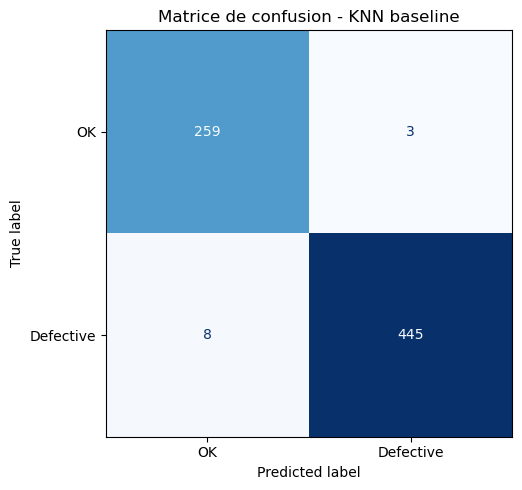

In [16]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["OK", "Defective"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Matrice de confusion - KNN baseline")
plt.tight_layout()
plt.show()